In [1]:
PROJECT_DIR = r"D:\Work\Projects\Facepoint Recognizer\Face-Orientation-Detector"


In [4]:
import torch

url = "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt"

filename = "yolo11n-seg.pt"

torch.hub.download_url_to_file(url, filename)
print(f"Model downloaded as {filename}")

100%|██████████| 5.90M/5.90M [00:00<00:00, 43.7MB/s]

Model downloaded as yolo11n-seg.pt


Loading Keypoint Model...


C:\Users\Aditya_Mishra\AppData\Local\Temp\ipykernel_28596\2606428344.py:222: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_WEIGHTS, ma

✓ Model weights loaded.
Processing image: D:\Work\Projects\Facepoint Recognizer\Face-Orientation-Detector/test.jpg


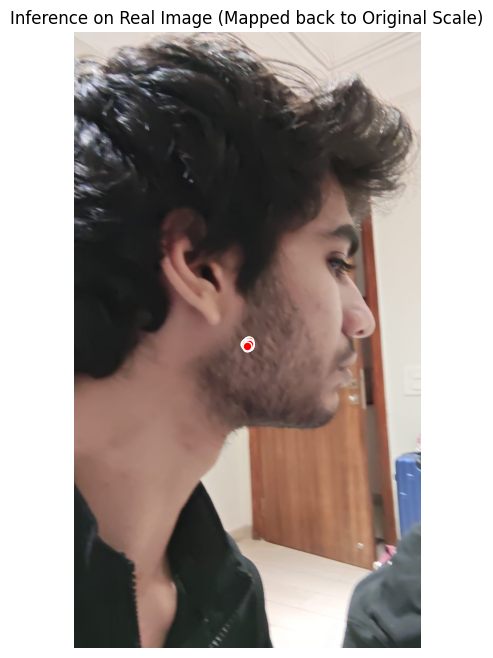

Done! If points are accurate, your pipeline is robust.


In [6]:
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import models
from ultralytics import YOLO

# ============================================================
# 1. CONFIGURATION
# ============================================================
# Path to your trained weights (Update if different)
MODEL_WEIGHTS = PROJECT_DIR + "/best_model.pth"

# Path to YOLO weights (used for cropping the person)
YOLO_WEIGHTS = PROJECT_DIR + "/yolo11n-seg.pt"

# Any real image path you want to test
TEST_IMAGE_PATH = PROJECT_DIR + "/test.jpg" 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 512
NUM_KPTS = 26

# ============================================================
# 2. MODEL ARCHITECTURE (Must Match Training EXACTLY)
# ============================================================
class Head(nn.Module):
    def __init__(self, c, k):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),

            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),

            nn.Conv2d(128, k, 1)
        )
    def forward(self, x): 
        return self.net(x)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # We don't need pretrained weights for inference, we load ours later
        m = models.mobilenet_v3_large(weights=None)
        c = m.features[0][0]

        g = nn.Conv2d(
            1, c.out_channels,
            kernel_size=c.kernel_size,
            stride=c.stride,
            padding=c.padding,
            bias=(c.bias is not None)
        )
        m.features[0][0] = g

        self.backbone = m.features
        self.head = Head(960, NUM_KPTS)

    def forward(self, x):
        return torch.sigmoid(self.head(self.backbone(x)))

def softargmax(hm, T=50.0):
    """ High temperature for sharp inference coordinates """
    B, K, H, W = hm.shape
    p = F.softmax(hm.view(B, K, -1) * T, dim=2).view(B, K, H, W)
    xs = torch.linspace(0, 1, W, device=hm.device)
    ys = torch.linspace(0, 1, H, device=hm.device)
    x = (p * xs.view(1,1,1,W)).sum((2,3))
    y = (p * ys.view(1,1,H,1)).sum((2,3))
    return torch.stack([x, y], -1)

# ============================================================
# 3. PREPROCESSING UTILS (From Your Original Code)
# ============================================================
# Initialize YOLO
if os.path.exists(YOLO_WEIGHTS):
    yolo_model = YOLO(YOLO_WEIGHTS)
else:
    print("Downloading fallback YOLO...")
    yolo_model = YOLO("yolov8n-seg.pt")

def get_person_crop_coords(img_bgr, margin_ratio=0.25):
    """
    Uses YOLO to find the largest person and returns the Square Crop Coordinates.
    Does NOT crop the image yet, just calculates the coordinates (x1, y1, x2, y2).
    """
    h, w = img_bgr.shape[:2]
    results = yolo_model(img_bgr, verbose=False)
    
    if not results or not results[0].boxes:
        # Fallback: Center crop if no person found
        center_x, center_y = w // 2, h // 2
        side = min(w, h)
        x1 = center_x - side // 2
        y1 = center_y - side // 2
        return x1, y1, x1 + side, y1 + side

    # Get boxes
    boxes = results[0].boxes.data.cpu().numpy() # x1, y1, x2, y2, conf, cls
    
    # Filter for Person class (0)
    person_boxes = [b for b in boxes if int(b[5]) == 0]
    
    if not person_boxes:
        # Fallback if detection exists but no person
        best_box = boxes[0] 
    else:
        # Pick largest person by area
        best_box = max(person_boxes, key=lambda b: (b[2]-b[0]) * (b[3]-b[1]))

    # Calculate Square Crop with Margin
    bx1, by1, bx2, by2 = best_box[:4]
    bw, bh = bx2 - bx1, by2 - by1
    cx, cy = bx1 + bw/2, by1 + bh/2
    
    side = max(bw, bh)
    pad = side * margin_ratio
    side_padded = side + 2 * pad
    
    x1 = int(cx - side_padded / 2)
    y1 = int(cy - side_padded / 2)
    x2 = int(cx + side_padded / 2)
    y2 = int(cy + side_padded / 2)
    
    return x1, y1, x2, y2

def crop_and_resize(img_bgr, coords, target_size=512):
    """
    Crops the image using coords (handling out-of-bounds via padding)
    and resizes to target_size.
    Returns: 
        processed_img (512, 512)
        scale_factor (float) - used to map points back
    """
    x1, y1, x2, y2 = coords
    h, w = img_bgr.shape[:2]
    
    # Calculate padding if crop is outside image
    pad_l = max(0, -x1)
    pad_t = max(0, -y1)
    pad_r = max(0, x2 - w)
    pad_b = max(0, y2 - h)
    
    # Pad the original image
    img_padded = cv2.copyMakeBorder(
        img_bgr, pad_t, pad_b, pad_l, pad_r, 
        cv2.BORDER_CONSTANT, value=(0,0,0)
    )
    
    # Adjust coords to padded space
    crop_x1 = x1 + pad_l
    crop_y1 = y1 + pad_t
    crop_x2 = x2 + pad_l
    crop_y2 = y2 + pad_t
    
    # Perform Crop
    crop = img_padded[crop_y1:crop_y2, crop_x1:crop_x2]
    
    # Resize
    crop_h, crop_w = crop.shape[:2]
    resized = cv2.resize(crop, (target_size, target_size))
    
    # Convert to Grayscale (Model expects 1 channel)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    # Normalize 0-1
    input_tensor = torch.from_numpy(gray).float() / 255.0
    input_tensor = input_tensor.unsqueeze(0).unsqueeze(0) # (1, 1, 512, 512)
    
    return input_tensor, crop_w

# ============================================================
# 4. INFERENCE PIPELINE
# ============================================================
def predict_on_raw_image(img_path, model):
    # 1. Load Image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Could not load image: {img_path}")
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Get Smart Crop Coordinates (using YOLO)
    x1, y1, x2, y2 = get_person_crop_coords(img_bgr)
    
    # 3. Process Image for Model
    input_tensor, crop_size_px = crop_and_resize(img_bgr, (x1, y1, x2, y2))
    input_tensor = input_tensor.to(DEVICE)
    
    # 4. Run Model
    with torch.no_grad():
        hm = model(input_tensor)
        # Get normalized coords (0.0 to 1.0)
        norm_coords = softargmax(hm).cpu().numpy()[0] 
        
    # 5. Map Keypoints back to Original Image Space
    # Formula: real_x = (norm_x * crop_size) + crop_origin_x
    real_kps = []
    for nx, ny in norm_coords:
        rx = (nx * crop_size_px) + x1
        ry = (ny * crop_size_px) + y1
        real_kps.append([rx, ry])
        
    return img_rgb, np.array(real_kps)

# ============================================================
# 5. MAIN EXECUTION
# ============================================================
print("Loading Keypoint Model...")
model = Net().to(DEVICE)
try:
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    print("✓ Model weights loaded.")
except FileNotFoundError:
    print(f"ERROR: Model weights not found at {MODEL_WEIGHTS}")
    print("Please check the path.")
    exit()

model.eval()

print(f"Processing image: {TEST_IMAGE_PATH}")
try:
    original_img, keypoints = predict_on_raw_image(TEST_IMAGE_PATH, model)

    # Visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(original_img)
    
    # Draw points
    plt.scatter(keypoints[:, 0], keypoints[:, 1], c='red', s=40, marker='o', edgecolors='white', linewidths=1)
    
    # Optional: Draw numbers to verify order
    # for i, (x, y) in enumerate(keypoints):
    #     plt.text(x, y, str(i), color='yellow', fontsize=8)

    plt.title("Inference on Real Image (Mapped back to Original Scale)")
    plt.axis('off')
    plt.show()
    
    print("Done! If points are accurate, your pipeline is robust.")

except Exception as e:
    print(f"Inference failed: {e}")